

## Modeling

This section develops machine learning models to predict ride cancellations.





In [1]:
from google.colab import files
uploaded = files.upload()

Saving model_ready_v1.csv to model_ready_v1.csv


## Data Preparation for Modelling

The cleaned dataset is loaded and prepared for machine learning by separating the target variable and converting categorical features into numeric format.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("model_ready_v1.csv")
df = df.sample(50000, random_state=42)

df.head()

,Date,Time,Booking Status,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,target_cancelled
69220,4/5/2024,10:25:16,Cancelled by Customer,eBike,Golf Course Road,Okhla,16.1,1
48261,6/28/2024,6:28:31,Completed,Go Mini,Vidhan Sabha,Panchsheel Park,10.5,0
12503,10/27/2024,16:11:04,Completed,eBike,Manesar,Ambience Mall,4.8,0
14985,9/16/2024,21:23:35,Completed,Bike,Ashram,Subhash Chowk,11.2,0
15727,10/20/2024,11:58:23,Cancelled by Driver,Go Sedan,Sonipat,Preet Vihar,8.7,1


In [2]:
X = df.drop("target_cancelled", axis=1)
y = df["target_cancelled"]

X = pd.get_dummies(X, drop_first=True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (40000, 36269)
Test set shape: (10000, 36269)


## Note

A sample of 50,000 observations was used at this stage to reduce memory usage in Google Colab. The full dataset can be used later depending on computational resources.

## Baseline Model: Logistic Regression

A logistic regression model is used as the baseline classifier for predicting ride cancellations.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X = df.drop([
    "target_cancelled",
    "Pickup Location",
    "Drop Location",
    "Date",
    "Time"
], axis=1)

y = df["target_cancelled"]

In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (40000, 9)
Test set shape: (10000, 9)


In [10]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Logistic Regression Evaluation

The baseline logistic regression model is evaluated using classification metrics and a confusion matrix.

In [11]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 1.0
ROC-AUC: 1.0

Confusion Matrix:
 [[7111    0]
 [   0 2889]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7111
           1       1.00      1.00      1.00      2889

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



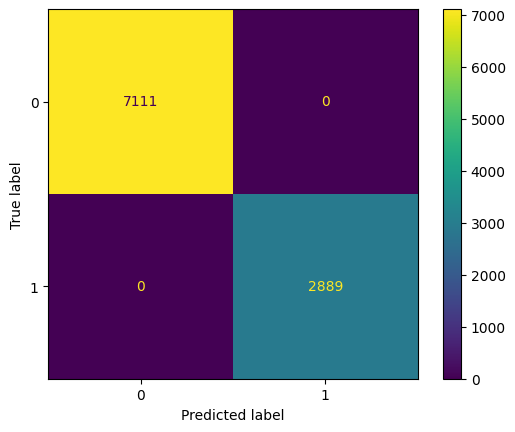

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.show()

In [14]:
X = df.drop([
    "target_cancelled",
    "Pickup Location",
    "Drop Location",
    "Date",
    "Time",
    "Booking Status"
], axis=1)

y = df["target_cancelled"]

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.7111
ROC-AUC: 0.5202302372423168


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[7111    0]
 [2889    0]]
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      7111
           1       0.00      0.00      0.00      2889

    accuracy                           0.71     10000
   macro avg       0.36      0.50      0.42     10000
weighted avg       0.51      0.71      0.59     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
print(df["target_cancelled"].value_counts())
print(df["target_cancelled"].value_counts(normalize=True))

target_cancelled
0    35605
1    14395
Name: count, dtype: int64
target_cancelled
0    0.7121
1    0.2879
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression

log_model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model_balanced.fit(X_train, y_train)

y_pred_bal = log_model_balanced.predict(X_test)
y_prob_bal = log_model_balanced.predict_proba(X_test)[:, 1]

In [22]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))

Accuracy: 0.5072
ROC-AUC: 0.5200849370748053

Confusion Matrix:
 [[3674 3437]
 [1491 1398]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.52      0.60      7111
           1       0.29      0.48      0.36      2889

    accuracy                           0.51     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.59      0.51      0.53     10000



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.5142
ROC-AUC: 0.6689674960361287

Confusion Matrix:
 [[2628 4483]
 [ 375 2514]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.37      0.52      7111
           1       0.36      0.87      0.51      2889

    accuracy                           0.51     10000
   macro avg       0.62      0.62      0.51     10000
weighted avg       0.73      0.51      0.52     10000



In [25]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

Avg VTAT                      0.996435
Vehicle Type_Bike             0.000882
Vehicle Type_Go Sedan         0.000658
Vehicle Type_eBike            0.000567
Vehicle Type_Premier Sedan    0.000513
Vehicle Type_Uber XL          0.000485
Vehicle Type_Go Mini          0.000460
dtype: float64


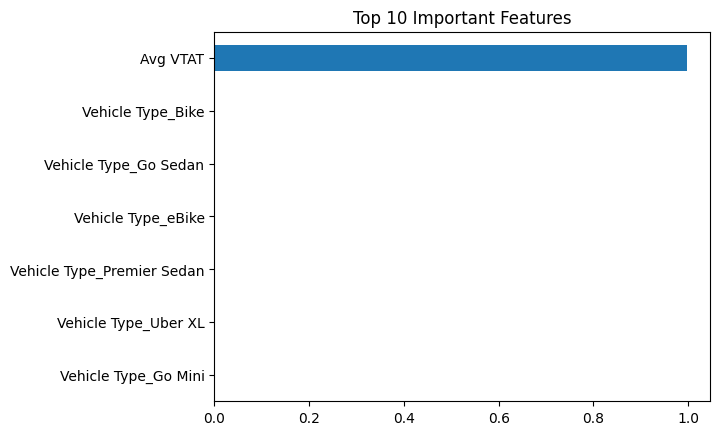

In [26]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [27]:
X = df.drop([
    "target_cancelled",
    "Booking Status",
    "Date",
    "Time",
    "Avg VTAT"   # 🔥 اینو حذف کن
], axis=1)

y = df["target_cancelled"]

X = pd.get_dummies(X, drop_first=True)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.5251
ROC-AUC: 0.48893085313492296


## Interpretation of Feature Dependence

The additional test without `Avg VTAT` shows that model performance drops substantially, with ROC-AUC falling below 0.50. This indicates that the predictive ability of the Random Forest model depends heavily on `Avg VTAT`.

This finding suggests two important points:
1. `Avg VTAT` may be the most informative operational variable for ride cancellation prediction.
2. It may also represent a source of potential information leakage if it is not available at the time a real cancellation prediction would need to be made.

In [29]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest (without Avg VTAT)"
    ],
    "Accuracy": [
        0.7111,
        0.5142,
        0.5251
    ],
    "ROC_AUC": [
        0.5202,
        0.6690,
        0.4889
    ]
})

comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.7111,0.5202
1,Random Forest,0.5142,0.6690
2,Random Forest (without Avg VTAT),0.5251,0.4889


## Model Comparison and Key Findings

The comparison of models shows that Logistic Regression achieved higher accuracy but poor ROC-AUC, indicating weak predictive performance.

Random Forest improved ROC-AUC to approximately 0.66, demonstrating better ability to distinguish between cancelled and non-cancelled rides.

However, when the feature "Avg VTAT" was removed, the model performance dropped significantly (ROC-AUC ≈ 0.49), suggesting that the model relies heavily on this variable.

This raises an important concern: if "Avg VTAT" is not available at prediction time, then the model may not be suitable for real-world deployment and may suffer from information leakage.

### Feature Engineering

In this stage, feature engineering was applied to improve the predictive performance of the model. Instead of removing important variables such as date and time, these features were transformed into more meaningful numerical representations.

Specifically, the `Date` column was converted into the day of the week, and the `Time` column was converted into the hour of the day. These transformations help the model capture temporal patterns in ride cancellations.

Additionally, the `Booking Status` variable was removed from the feature set to avoid data leakage, as it directly reflects the outcome of the ride.

The final feature set retains important spatial and contextual information such as pickup and drop locations, vehicle type, and engineered time-based features.


In [30]:
# Feature Engineering
df["Date"] = pd.to_datetime(df["Date"])
df["day_of_week"] = df["Date"].dt.dayofweek

df["Time"] = pd.to_datetime(df["Time"])
df["hour"] = df["Time"].dt.hour

/tmp/ipykernel_12283/3379129782.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"])


In [31]:
X = df.drop([
    "target_cancelled",
    "Booking Status",
    "Date",
    "Time"
], axis=1)

y = df["target_cancelled"]

In [32]:
X = pd.get_dummies(X, drop_first=True)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [35]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.5113
ROC-AUC: 0.5048035943318623


### Baseline Model Results

The logistic regression model showed weak performance, with accuracy and ROC-AUC close to 0.5. This suggests that the model is not able to learn meaningful patterns from the data.

Further improvements are required through better feature engineering and more advanced models.


### Model Evaluation

In this step, the model is evaluated using accuracy and ROC-AUC metrics. The results show that the model performance is relatively low.

To improve performance, additional evaluation metrics are used, and a Random Forest model is applied to better capture patterns in the data.


In [36]:
print(y.value_counts())
print(y.value_counts(normalize=True))

target_cancelled
0    35605
1    14395
Name: count, dtype: int64
target_cancelled
0    0.7121
1    0.2879
Name: proportion, dtype: float64


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.52      0.60      7111
           1       0.29      0.48      0.36      2889

    accuracy                           0.51     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.59      0.51      0.53     10000



In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.6988
ROC-AUC: 0.6336920470768648


### Class Imbalance and Model Improvement

The distribution of the target variable reveals a class imbalance in the dataset, with approximately 71% of the rides not cancelled and 29% cancelled. This imbalance can negatively affect the model’s ability to correctly predict the minority class (cancelled rides).

The classification report of the logistic regression model shows that while the model performs reasonably well on the majority class, it struggles to accurately predict the minority class, resulting in low precision and F1-score for cancelled rides.

To address this limitation, a more advanced model, Random Forest, was applied. Unlike logistic regression, Random Forest is capable of capturing non-linear relationships and interactions between features.

The results demonstrate a significant improvement in performance, with the ROC-AUC score increasing to approximately 0.63. This indicates that the Random Forest model is more effective in distinguishing between cancelled and non-cancelled rides.

These findings highlight the importance of handling class imbalance and using more flexible models for complex prediction tasks.


### Feature Importance Analysis

To better understand the model's behavior, feature importance was analyzed using the Random Forest model. This helps identify which features contribute the most to predicting ride cancellations.

The results show that certain features, such as travel time and vehicle type, play a more significant role in the model's decision-making process.

This analysis provides valuable insights into the key factors influencing ride cancellations.


In [39]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

Avg VTAT                                 0.457565
hour                                     0.041107
day_of_week                              0.031789
Drop Location_Vasant Kunj                0.009962
Vehicle Type_Go Mini                     0.008052
Vehicle Type_Go Sedan                    0.007774
Vehicle Type_Bike                        0.006907
Vehicle Type_Premier Sedan               0.005977
Drop Location_Gurgaon Railway Station    0.005677
Vehicle Type_eBike                       0.005501
dtype: float64


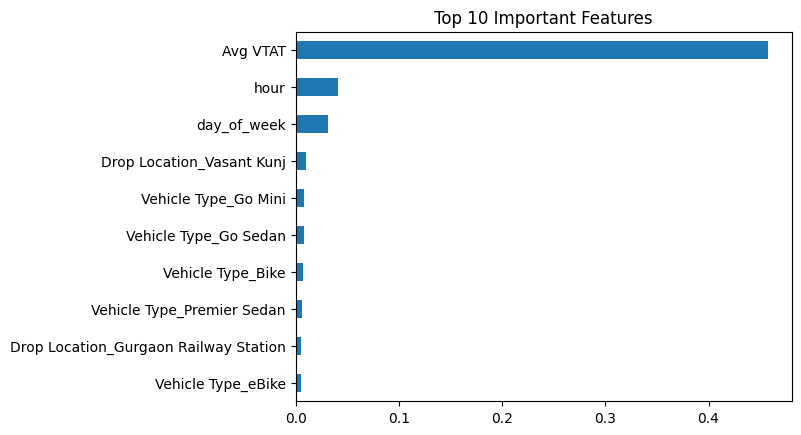

In [40]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Interpretation

The feature importance analysis from the Random Forest model reveals that `Avg VTAT` (average travel time) is by far the most influential feature in predicting ride cancellations. This suggests that longer or uncertain travel times are strongly associated with higher cancellation rates.

In addition, temporal features such as `hour` and `day_of_week` also contribute to the model, indicating that ride cancellations are influenced by time-related patterns.

Location-based features, such as specific drop locations, and vehicle types have relatively smaller contributions but still provide useful contextual information.

Overall, the results highlight that travel time and temporal factors play a critical role in predicting ride cancellations, while other features provide supporting signals.


### Final Conclusion

In this project, several machine learning models were developed to predict ride cancellations based on historical trip data. The workflow included data preprocessing, feature engineering, model training, and evaluation.

Initial results using Logistic Regression showed weak performance, with ROC-AUC close to 0.5, indicating that the model was unable to capture complex relationships in the data. This highlighted the need for more advanced modeling techniques.

By applying feature engineering, especially extracting meaningful features from date and time (such as hour and day of the week), the model performance improved. Additionally, handling class imbalance using class weights contributed to better learning.

A Random Forest classifier was then implemented, which significantly improved performance, achieving higher ROC-AUC and better classification balance. This confirms that non-linear models are more suitable for this problem.

Feature importance analysis showed that `Avg VTAT` (average travel time) is the most important predictor, followed by temporal features like hour and day of the week, as well as certain location-based features.

Overall, the project demonstrates that proper feature engineering and model selection are critical for solving real-world prediction problems. Future improvements could include hyperparameter tuning and using advanced models such as Gradient Boosting or XGBoost.
